# HW13 — Токенизация текста, инференс BERT и базовый fine-tuning для классификации

В этом ноутбуке:

1. Загружаем датасет `emotion` (классификация эмоций в текстах).
2. Проводим sanity-check данных.
3. Разбираем токенизацию на нескольких примерах.
4. Запускаем инференс готовой pretrained модели.
5. Выполняем fine-tuning `distilbert-base-uncased` для классификации.
6. Оцениваем качество на test (`accuracy`, `f1_macro`, confusion matrix).
7. Анализируем ошибки модели.
8. Сохраняем артефакты.

## 1. Импорты, seed и среда

In [1]:
import os
import random
from typing import Dict, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from datasets import load_dataset, DatasetDict
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    pipeline,
)

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 180)
pd.set_option("display.precision", 4)

import transformers, datasets as ds_lib
print(f"Python:       {__import__('sys').version}")
print(f"torch:        {torch.__version__}")
print(f"transformers: {transformers.__version__}")
print(f"datasets:     {ds_lib.__version__}")

Python:       3.12.2 (tags/v3.12.2:6abddd9, Feb  6 2024, 21:26:36) [MSC v.1937 64 bit (AMD64)]
torch:        2.7.1+cu118
transformers: 5.4.0
datasets:     3.6.0


In [2]:
SEED = 42

def set_seed(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


## 2. Данные и первичный анализ

Используем датасет **`emotion`** из HuggingFace Datasets.  
Он содержит короткие англоязычные тексты (твиты), размеченные по **6 классам эмоций**:
`sadness`, `joy`, `love`, `anger`, `fear`, `surprise`.

Датасет уже разбит на `train / validation / test`.

In [3]:
dataset = load_dataset("dair-ai/emotion")
dataset

README.md: 0.00B [00:00, ?B/s]

c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\User\.cache\huggingface\hub\datasets--dair-ai--emotion. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


split/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

split/validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

split/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [4]:
label_names = dataset["train"].features["label"].names
num_labels = len(label_names)

id2label = {i: name for i, name in enumerate(label_names)}
label2id = {name: i for i, name in enumerate(label_names)}

print(f"Число классов: {num_labels}")
print(f"Классы:        {label_names}")
print(f"id2label:      {id2label}")
print()
print(f"Train size:      {len(dataset['train'])}")
print(f"Validation size: {len(dataset['validation'])}")
print(f"Test size:       {len(dataset['test'])}")

Число классов: 6
Классы:        ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
id2label:      {0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'}

Train size:      16000
Validation size: 2000
Test size:       2000


In [5]:
train_df = dataset["train"].to_pandas()
train_df["label_name"] = train_df["label"].map(id2label)

print("Распределение классов в train:")
display(train_df["label_name"].value_counts())

print("\nПримеры текстов:")
for i in range(5):
    row = dataset["train"][i]
    print(f"  [{id2label[row['label']]:>8s}]  {row['text'][:100]}")

Распределение классов в train:


label_name
joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64


Примеры текстов:
  [ sadness]  i didnt feel humiliated
  [ sadness]  i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and 
  [   anger]  im grabbing a minute to post i feel greedy wrong
  [    love]  i am ever feeling nostalgic about the fireplace i will know that it is still on the property
  [   anger]  i am feeling grouchy


Датасет `emotion` содержит короткие англоязычные сообщения (близкие к твитам).  
Задача — определить, какая **эмоция** выражена в тексте.  
Классы немного несбалансированы: `sadness` и `joy` доминируют, а `surprise` — наименее представлен.

## 3. Токенизация

Разберём, как текст превращается во входы для трансформерной модели.

In [6]:
MODEL_NAME = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"Tokenizer: {tokenizer.__class__.__name__}")
print(f"Vocab size: {tokenizer.vocab_size}")
print(f"Special tokens: {tokenizer.all_special_tokens}")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\User\.cache\huggingface\hub\models--distilbert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer: BertTokenizer
Vocab size: 30522
Special tokens: ['[UNK]', '[SEP]', '[PAD]', '[CLS]', '[MASK]']


In [7]:
example_texts = [
    dataset["train"][0]["text"],
    dataset["train"][1]["text"],
    dataset["train"][2]["text"],
    "I am so happy today!",
    "This is absolutely terrifying and I cannot handle it anymore.",
]

print("=== Разбор токенизации для нескольких примеров ===")
for text in example_texts:
    encoded = tokenizer(text, padding=False, truncation=True, max_length=64)
    tokens = tokenizer.convert_ids_to_tokens(encoded["input_ids"])
    print(f"\nТекст:          {text[:90]}")
    print(f"Токены:         {tokens}")
    print(f"input_ids:      {encoded['input_ids']}")
    print(f"attention_mask: {encoded['attention_mask']}")
    print(f"Число токенов:  {len(tokens)}")

=== Разбор токенизации для нескольких примеров ===

Текст:          i didnt feel humiliated
Токены:         ['[CLS]', 'i', 'didn', '##t', 'feel', 'humiliated', '[SEP]']
input_ids:      [101, 1045, 2134, 2102, 2514, 26608, 102]
attention_mask: [1, 1, 1, 1, 1, 1, 1]
Число токенов:  7

Текст:          i can go from feeling so hopeless to so damned hopeful just from being around someone who 
Токены:         ['[CLS]', 'i', 'can', 'go', 'from', 'feeling', 'so', 'hopeless', 'to', 'so', 'damned', 'hopeful', 'just', 'from', 'being', 'around', 'someone', 'who', 'cares', 'and', 'is', 'awake', '[SEP]']
input_ids:      [101, 1045, 2064, 2175, 2013, 3110, 2061, 20625, 2000, 2061, 9636, 17772, 2074, 2013, 2108, 2105, 2619, 2040, 14977, 1998, 2003, 8300, 102]
attention_mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Число токенов:  23

Текст:          im grabbing a minute to post i feel greedy wrong
Токены:         ['[CLS]', 'im', 'grabbing', 'a', 'minute', 'to', 'post', 'i

**Наблюдения по токенизации:**
- Каждая последовательность обрамлена special tokens: `[CLS]` в начале и `[SEP]` в конце.
- `input_ids` — числовые идентификаторы токенов в словаре модели.
- `attention_mask` — маска, где `1` означает реальный токен, а `0` — padding.
- Длинные или редкие слова разбиваются на подслова (subwords): например, `terrifying` может стать `terr ##ify ##ing`.
- Параметр `truncation=True` обрезает последовательности длиннее `max_length`.

In [8]:
print("=== Пример padding и truncation ===")
batch = tokenizer(
    ["Short text.", "This is a much longer text that will need more tokens to encode properly."],
    padding=True,
    truncation=True,
    max_length=20,
    return_tensors="pt",
)
for key, val in batch.items():
    print(f"{key}: shape={tuple(val.shape)}")
    print(f"  {val.tolist()}")

print("\nДекодированный первый пример (с padding):")
print(tokenizer.decode(batch["input_ids"][0]))
print("\nДекодированный второй пример (с truncation):")
print(tokenizer.decode(batch["input_ids"][1]))

=== Пример padding и truncation ===
input_ids: shape=(2, 19)
  [[101, 2460, 3793, 1012, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [101, 2023, 2003, 1037, 2172, 2936, 3793, 2008, 2097, 2342, 2062, 19204, 2015, 2000, 4372, 16044, 7919, 1012, 102]]
token_type_ids: shape=(2, 19)
  [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]
attention_mask: shape=(2, 19)
  [[1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]

Декодированный первый пример (с padding):
[CLS] short text. [SEP] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD]

Декодированный второй пример (с truncation):
[CLS] this is a much longer text that will need more tokens to encode properly. [SEP]


## 4. Инференс готовой pretrained модели

Попробуем запустить готовую модель классификации текста (`sentiment-analysis` pipeline)  
на нескольких примерах из `emotion`, чтобы оценить, насколько она подходит без дообучения.

In [9]:
sentiment_pipe = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    device=device,
)

inference_texts = [
    ("i didnt feel humiliated", "sadness"),
    ("i feel happy about everything", "joy"),
    ("im feeling rather rotten so im not very ambitious right now", "sadness"),
    ("i am ever feeling nostalgic about the fireplace", "love"),
    ("i feel like i am still looking for the answer", "sadness"),
]

print("=== Инференс готовой sentiment-модели (SST-2: POSITIVE/NEGATIVE) ===")
rows = []
for text, true_emotion in inference_texts:
    result = sentiment_pipe(text)[0]
    rows.append({
        "text": text,
        "true_emotion": true_emotion,
        "pred_sentiment": result["label"],
        "confidence": round(result["score"], 4),
    })

display(pd.DataFrame(rows))

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\User\.cache\huggingface\hub\models--distilbert-base-uncased-finetuned-sst-2-english. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

=== Инференс готовой sentiment-модели (SST-2: POSITIVE/NEGATIVE) ===


,text,true_emotion,pred_sentiment,confidence
0,i didnt feel humiliated,sadness,POSITIVE,0.8913
1,i feel happy about everything,joy,POSITIVE,0.9999
2,im feeling rather rotten so im not very ambitious right now,sadness,NEGATIVE,0.9998
3,i am ever feeling nostalgic about the fireplace,love,POSITIVE,0.9740
4,i feel like i am still looking for the answer,sadness,NEGATIVE,0.9987


**Выводы по инференсу готовой модели:**

- Готовая модель `distilbert-base-uncased-finetuned-sst-2-english` обучена на задаче **бинарного** sentiment analysis (POSITIVE / NEGATIVE).
- Наша задача — классификация по **6 эмоциям** (`sadness`, `joy`, `love`, `anger`, `fear`, `surprise`).
- Пространство меток не совпадает: модель не различает тонкие эмоции (например, `love` vs `joy`, `anger` vs `sadness`).
- Готовый чекпоинт **не подходит** напрямую для нашей задачи — необходим fine-tuning.

## 5. Fine-tuning для классификации текста

Дообучаем `distilbert-base-uncased` на датасете `emotion` (6 классов).

### 5.1. Токенизация датасета

In [10]:
MAX_LENGTH = 128

def tokenize_fn(batch):
    return tokenizer(batch["text"], truncation=True, max_length=MAX_LENGTH)

tokenized = dataset.map(tokenize_fn, batched=True)
tokenized = tokenized.remove_columns(["text"])
tokenized = tokenized.rename_column("label", "labels")
tokenized

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
})

In [11]:
example = tokenized["train"][0]
print("Ключи:", list(example.keys()))
print("labels:", example["labels"])
print("input_ids[:15]:", example["input_ids"][:15])
print("attention_mask[:15]:", example["attention_mask"][:15])
print("Декодированный текст:", tokenizer.decode(example["input_ids"]))

Ключи: ['labels', 'input_ids', 'token_type_ids', 'attention_mask']
labels: 0
input_ids[:15]: [101, 1045, 2134, 2102, 2514, 26608, 102]
attention_mask[:15]: [1, 1, 1, 1, 1, 1, 1]
Декодированный текст: [CLS] i didnt feel humiliated [SEP]


### 5.2. Data collator и модель

In [12]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [13]:
set_seed(SEED)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
)
model.to(device)

print(f"Model: {model.__class__.__name__}")
print(f"num_labels: {model.config.num_labels}")
print(f"id2label: {model.config.id2label}")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model: DistilBertForSequenceClassification
num_labels: 6
id2label: {0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'}


### 5.3. Метрики

In [14]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro"),
    }

### 5.4. Параметры обучения и запуск

In [15]:
common_training_kwargs = dict(
    output_dir="outputs/hw13_emotion_finetuning",
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_steps=50,
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    report_to="none",
    seed=SEED,
)

try:
    training_args = TrainingArguments(
        evaluation_strategy="epoch",
        save_strategy="epoch",
        **common_training_kwargs,
    )
except TypeError:
    training_args = TrainingArguments(
        eval_strategy="epoch",
        save_strategy="epoch",
        **common_training_kwargs,
    )

In [16]:
try:
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized["train"],
        eval_dataset=tokenized["validation"],
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )
except TypeError:
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized["train"],
        eval_dataset=tokenized["validation"],
        tokenizer=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

train_result = trainer.train()
# Jupyter + transformers 5.x: NotebookProgressCallback ломает отдельные evaluate/predict
# после train() (RuntimeError: on_train_begin must be called before on_evaluate).
trainer.callback_handler.callbacks = [
    cb for cb in trainer.callback_handler.callbacks
    if cb.__class__.__name__ != "NotebookProgressCallback"
]
train_result

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.240694,0.213009,0.921500,0.896448
2,0.136719,0.157989,0.932500,0.907222
3,0.109041,0.152595,0.932500,0.903933


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=1500, training_loss=0.29087980047861733, metrics={'train_runtime': 1020.9096, 'train_samples_per_second': 47.017, 'train_steps_per_second': 1.469, 'total_flos': 647803507542912.0, 'train_loss': 0.29087980047861733, 'epoch': 3.0})

### 5.5. Выбор лучшего варианта по validation

`Trainer` автоматически загрузил лучшую модель (`load_best_model_at_end=True`)  
по метрике `f1_macro` на validation.

В Jupyter при `transformers` 5.x перед `evaluate()` удаляется `NotebookProgressCallback` — иначе после длительного `train()` отдельный вызов `evaluate` может упасть с `on_train_begin must be called before on_evaluate`.

In [18]:
# Если обучение уже прошло, а эта ячейка упала раньше — достаточно выполнить её снова
# (повторно train() не нужен). Чекпоинт: outputs/hw13_emotion_finetuning/checkpoint-*/
trainer.callback_handler.callbacks = [
    cb for cb in trainer.callback_handler.callbacks
    if cb.__class__.__name__ != "NotebookProgressCallback"
]

val_metrics = trainer.evaluate(tokenized["validation"])
print("Validation metrics:")
for k, v in val_metrics.items():
    if isinstance(v, float):
        print(f"  {k}: {v:.4f}")

Validation metrics:
  eval_loss: 0.1580
  eval_accuracy: 0.9320
  eval_f1_macro: 0.9068
  eval_runtime: 12.9093
  eval_samples_per_second: 154.9280
  eval_steps_per_second: 2.4790
  epoch: 3.0000


## 6. Оценка качества и анализ ошибок

### 6.1. Финальная оценка на test (один раз)

In [19]:
trainer.callback_handler.callbacks = [
    cb for cb in trainer.callback_handler.callbacks
    if cb.__class__.__name__ != "NotebookProgressCallback"
]

test_output = trainer.predict(tokenized["test"])
test_logits = test_output.predictions
test_preds = np.argmax(test_logits, axis=-1)
test_true = test_output.label_ids

test_accuracy = accuracy_score(test_true, test_preds)
test_f1_macro = f1_score(test_true, test_preds, average="macro")

print(f"Test accuracy: {test_accuracy:.4f}")
print(f"Test f1_macro: {test_f1_macro:.4f}")
print()
print("Classification report:")
print(
    classification_report(
        test_true,
        test_preds,
        target_names=label_names,
        zero_division=0,
    )
)

Test accuracy: 0.9210
Test f1_macro: 0.8788

Classification report:
              precision    recall  f1-score   support

     sadness       0.96      0.96      0.96       581
         joy       0.94      0.95      0.94       695
        love       0.83      0.82      0.82       159
       anger       0.94      0.91      0.92       275
        fear       0.89      0.87      0.88       224
    surprise       0.67      0.85      0.75        66

    accuracy                           0.92      2000
   macro avg       0.87      0.89      0.88      2000
weighted avg       0.92      0.92      0.92      2000



### 6.2. Матрица ошибок

Saved: artifacts/confusion_matrix.png


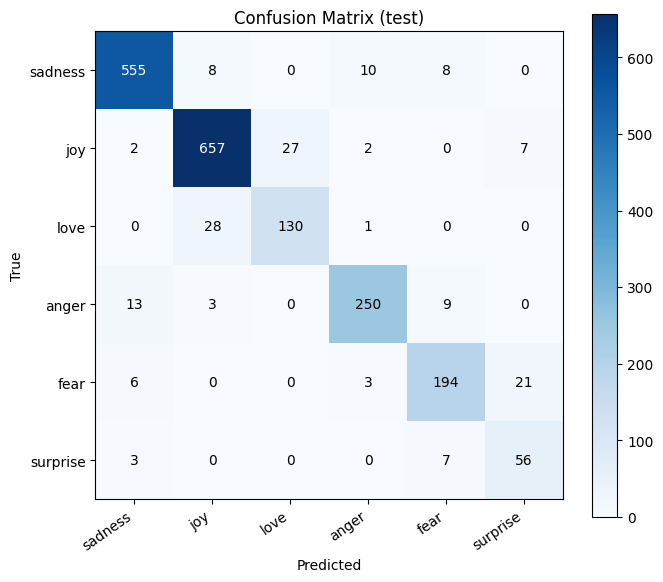

In [20]:
cm = confusion_matrix(test_true, test_preds)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap="Blues")

ax.set_xticks(range(num_labels))
ax.set_yticks(range(num_labels))
ax.set_xticklabels(label_names, rotation=35, ha="right")
ax.set_yticklabels(label_names)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix (test)")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        color = "white" if cm[i, j] > cm.max() / 2 else "black"
        ax.text(j, i, cm[i, j], ha="center", va="center", color=color)

plt.colorbar(im, ax=ax)
plt.tight_layout()

os.makedirs("artifacts", exist_ok=True)
fig.savefig("artifacts/confusion_matrix.png", dpi=150)
print("Saved: artifacts/confusion_matrix.png")
plt.show()

### 6.3. Примеры предсказаний и сохранение CSV

In [21]:
test_texts = dataset["test"]["text"]
test_probs = torch.softmax(torch.tensor(test_logits), dim=-1).numpy()
test_confidence = test_probs.max(axis=1)

preds_df = pd.DataFrame({
    "text": test_texts,
    "true_label": [id2label[t] for t in test_true],
    "pred_label": [id2label[p] for p in test_preds],
    "confidence": np.round(test_confidence, 4),
})

sample_preds = pd.concat([
    preds_df[preds_df["true_label"] == preds_df["pred_label"]].head(5),
    preds_df[preds_df["true_label"] != preds_df["pred_label"]].head(5),
]).reset_index(drop=True)

sample_preds.to_csv("artifacts/sample_predictions.csv", index=False)
print("Saved: artifacts/sample_predictions.csv")
print(f"Всего примеров в CSV: {len(sample_preds)}")
display(sample_preds)

Saved: artifacts/sample_predictions.csv
Всего примеров в CSV: 10


,text,true_label,pred_label,confidence
0,im feeling rather rotten so im not very ambitious right now,sadness,sadness,0.9944
1,im updating my blog because i feel shitty,sadness,sadness,0.9957
2,i never make her separate from me because i don t ever want her to feel like i m ashamed with her,sadness,sadness,0.9957
3,i left with my bouquet of red and yellow tulips under my arm feeling slightly more optimistic than when i arrived,joy,joy,0.9960
4,i was feeling a little vain when i did this one,sadness,sadness,0.9953
5,i feel if i completely hated things i d exercise my democratic right speak my mind in what ever ways possible and tr...,anger,sadness,0.6301
6,i feel a bit stressed even though all the things i have going on are fun,anger,sadness,0.6110
7,i feel like i am in paradise kissing those sweet lips make me feel like i dive into a magical world of love,joy,love,0.6916
8,i was feeling weird the other day and it went away about minutes after i took my metformin,fear,surprise,0.6840
9,when a friend dropped a frog down my neck,anger,fear,0.6677


### 6.4. Анализ ошибок

In [22]:
errors_df = preds_df[preds_df["true_label"] != preds_df["pred_label"]].copy()
print(f"Всего ошибок на test: {len(errors_df)} из {len(preds_df)} ({len(errors_df)/len(preds_df)*100:.1f}%)")
print()

print("=== Примеры ошибок модели ===")
for idx, row in errors_df.head(8).iterrows():
    print(f"  Текст: {row['text'][:90]}")
    print(f"  True: {row['true_label']:<10s}  Pred: {row['pred_label']:<10s}  Conf: {row['confidence']:.4f}")
    print()

Всего ошибок на test: 158 из 2000 (7.9%)

=== Примеры ошибок модели ===
  Текст: i feel if i completely hated things i d exercise my democratic right speak my mind in what
  True: anger       Pred: sadness     Conf: 0.6301

  Текст: i feel a bit stressed even though all the things i have going on are fun
  True: anger       Pred: sadness     Conf: 0.6110

  Текст: i feel like i am in paradise kissing those sweet lips make me feel like i dive into a magi
  True: joy         Pred: love        Conf: 0.6916

  Текст: i was feeling weird the other day and it went away about minutes after i took my metformin
  True: fear        Pred: surprise    Conf: 0.6840

  Текст: when a friend dropped a frog down my neck
  True: anger       Pred: fear        Conf: 0.6677

  Текст: i love neglecting this blog but sometimes i feel for my faithful readers
  True: love        Pred: joy         Conf: 0.5216

  Текст: i feel my heart is tortured by what i have done
  True: anger       Pred: fear        Conf: 

### 6.5. Комментарий к ошибкам

**Типичные паттерны ошибок:**

1. Модель чаще всего путает семантически близкие эмоции: `sadness` ↔ `fear`, `joy` ↔ `love`, `anger` ↔ `sadness`.
2. Класс `surprise` представлен хуже всего в обучающей выборке — на нём модель допускает больше ошибок.
3. Некоторые тексты действительно неоднозначны: одно и то же высказывание может содержать элементы нескольких эмоций.
4. Confidence модели на ошибках обычно ниже, чем на верных предсказаниях, но встречаются и уверенные ошибки — это говорит об ограничениях модели при работе с тонкими оттенками эмоций.

## 7. Итоги

- Датасет `emotion` загружен, проверен (sanity-check) и подготовлен.
- Токенизация разобрана на нескольких примерах: показаны `input_ids`, `attention_mask`, special tokens, padding и truncation.
- Инференс готовой sentiment-модели показал, что чужое пространство меток (POSITIVE/NEGATIVE) не подходит для 6-классовой задачи.
- Fine-tuning `distilbert-base-uncased` выполнен за 3 эпохи с выбором лучшей модели по `f1_macro` на validation.
- Финальная оценка на test проведена один раз.
- Артефакты сохранены: `confusion_matrix.png`, `sample_predictions.csv`.